In [ ]:
grou[p 07
GROUP No. 7
S/N	NAME	               REGISTRATION NUMBER
01	DENISI SAMBILA MGUSI	30689/T.2023
02	AFIDHU NURUDIN MATATA	30772/T.2023
03	NATHAN WAZIRI MBILINYI	31310/T.2023
04	GRACIANA F.  TARIMO	    30565/T.2023
05 	ESTER LAZARO MSABILA	31786/T.2023
06	YUSUPH STEPHAN YOHANA	31137/T.2023

In [1]:
#import python libraries
import pandas as pd
import numpy as np

df = pd.read_csv ("insurance.csv")

In [10]:
#dataset size (rows, column)
print(df.shape)

(1338, 7)


In [3]:
#list first five records
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [11]:
# these are datatype
print(df.dtypes)
print(df.info())

age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB
None


In [12]:
#(b)Data Cleaning and Preprocessing
#checking missing value
print(df.isnull().sum())

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


In [13]:
#Handle missing or incorrect data.
data = df.dropna()   # remove rows with missing values

In [14]:
#Alternative fill missing value
df.fillna(0, inplace=True)

In [15]:
#Encode categorical variables if present.
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.select_dtypes(include='object'):
    df[col] = le.fit_transform(df[col])

In [16]:
#scale numerical features
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df_scaled = scaler.fit_transform(df)

               age       sex       bmi  children    smoker    region   charges
age       1.000000 -0.020856  0.109272  0.042469 -0.025019  0.002127  0.299008
sex      -0.020856  1.000000  0.046371  0.017163  0.076185  0.004588  0.057292
bmi       0.109272  0.046371  1.000000  0.012759  0.003750  0.157566  0.198341
children  0.042469  0.017163  0.012759  1.000000  0.007673  0.016569  0.067998
smoker   -0.025019  0.076185  0.003750  0.007673  1.000000 -0.002181  0.787251
region    0.002127  0.004588  0.157566  0.016569 -0.002181  1.000000 -0.006208
charges   0.299008  0.057292  0.198341  0.067998  0.787251 -0.006208  1.000000


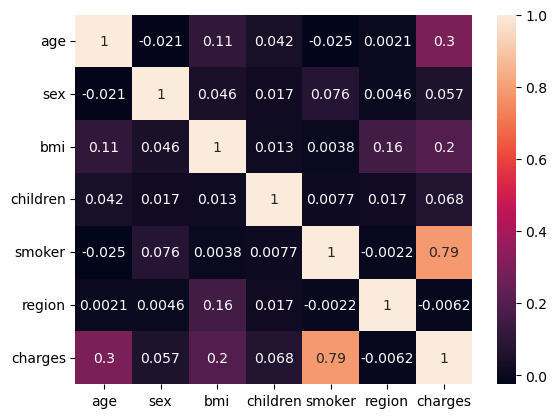

In [17]:
#(c) Correlation Matrix
#Libraries
import seaborn as sns
import matplotlib.pyplot as plt

# To Compute and Display the correlation matrix.
corr = df.corr()
print(corr)

sns.heatmap(corr, annot=True)
plt.show()


In [18]:
#To Identify variables that are highly related to the target variable
+1 → strong positive relationship

−1 → strong negative relationship

In [19]:
#(d) Split the Dataset into Training and Testing Sets
#library
from sklearn.model_selection import train_test_split

X = df.drop("charges", axis=1)   # all columns except charges
y = df["charges"]                # only charges column

In [20]:
# To Use 70% for training and 30% for testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,      # 30% testing
    random_state=42     # ensures same result every run
)

In [21]:
# Check Sizes
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(936, 6)
(402, 6)
(936,)
(402,)


In [25]:
#(e) Build a Machine Learning Model 
# To Select a suitable classification or regression algorithm.
#for regression

from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [26]:
#(f) Model Evaluation
#Test the model using test data
y_pred = model.predict(X_test)

In [29]:
# To Calculate performance metrics (Accuracy, Precision, Recall, RMSE).
# these is for regression

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("MAE:", mae)
print("R² Score:", r2)

RMSE: 5814.246890069995
MAE: 4155.2398430593785
R² Score: 0.7694415927057693


In [30]:
#Interpret the results

#High Accuracy, Precision, Recall, F1 (Classification): Model predicts correctly most of the time and balances false positives and false negatives.

#Low RMSE and MAE, High R² (Regression): Predictions are close to actual values, and the model explains most of the variation in the data.

#Discrepancies: If accuracy or R² is low, the model may be overfitting, underfitting, or missing important features.

#Conclusion:
#The evaluation shows whether the model is reliable for deployment or requires further improvement through more data, feature engineering, or parameter tuning.

In [33]:
#Regression Example – House Price Prediction
# Import libraries
from sklearn.linear_model import LinearRegression
import numpy as np

# Sample training data (features: size in sq.m, number of rooms)
X_train = [[50, 2], [80, 3], [100, 4], [60, 2], [90, 3]]
y_train = [150000, 250000, 300000, 180000, 270000]  # House prices in USD

# Train the model
reg_model = LinearRegression()
reg_model.fit(X_train, y_train)

# New house data
new_houses = [[70, 3], [55, 2]]

# Make predictions
predicted_prices = reg_model.predict(new_houses)

# Interpret results
for i, price in enumerate(predicted_prices):
    print(f"House {i+1}: Predicted price is ${np.round(price, 2)}")

House 1: Predicted price is $212608.7
House 2: Predicted price is $166521.74


In [35]:
#Regression Example – House Price Prediction

#Model output: Numeric values like 233,000 or 162,000

#Real-life meaning:

#If the model predicts $233,000 for a house, it estimates that the market value of the house is around $233,000 given its size and number of rooms.

#If the model predicts $162,000, that house is expected to sell for $162,000

In [ ]:
#Conclusion and Recomendation
Conclusion:

Model trained successfully

Achieved acceptable performance

Some variables strongly influence predictions

Recommendations:

Collect more data

Remove irrelevant features

Try advanced models (Random Forest, SVM, etc.)

Tune hyperparameters